# Phase 2 Analysis — Superstore Dataset

---
## Setup

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
db_path = Path('../data/superstore.db')
conn = sqlite3.connect(db_path)
df = pd.read_sql_query('SELECT * FROM orders', conn)
conn.close()

print(f'Records loaded: {len(df):,}')
print(f'Columns: {list(df.columns)}')

Records loaded: 9,993
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## Section 1: Discount Policy and Profit Erosion

**Objective:** Move from description to business interpretation. The core question is not *what* the discount levels are, but *whether they are justified* — and whether the profit losses observed are the result of discount policy or structural cost problems.

**Analytical frame:**
$$\text{Observed Margin} = \text{Base Margin}_{(d=0\%)} + \text{Discount-Driven Erosion}$$

Separating these two components determines whether a recommendation targets pricing, costs, or commercial policy.

**Questions addressed in Section 1:**
- **1.1** What is the safe discount ceiling per sub-category before margin turns negative?
- **1.2** How much profit has over-discounting destroyed — best case, assuming customers keep buying once discounts are capped (zero elasticity)?
- **1.3** Flat 20% cap vs. differentiated per-sub-category limits — which policy, and is the added complexity worth it?
- **1.4** Sales-fragility floor — if every over-discounted customer walked away instead, what profit would remain?

---
## 1.1 — Optimal Discount Policy by Sub-Category

### Approach

Two-step analysis:

1. **Heatmap (visual support):** Profit margin across discount buckets for every sub-category. Shows where and how fast margins deteriorate as discounts increase — the visual basis for every recommendation.
2. **Breakeven calculation:** For each sub-category, identify the last discount bucket where margin remains positive. That upper bound becomes the recommended maximum discount.

> **Methodological note on elasticity:** This dataset contains historical transaction records, not a controlled pricing experiment. We cannot measure true price-demand elasticity. Volume patterns by discount bucket are treated as descriptive evidence, not causal claims.

In [3]:
BUCKET_ORDER = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']

def assign_bucket(d):
    if d == 0:       return '0%'
    elif d <= 0.10:  return '1-10%'
    elif d <= 0.20:  return '11-20%'
    elif d <= 0.30:  return '21-30%'
    elif d <= 0.50:  return '31-50%'
    else:            return '>50%'

df['discount_bucket'] = df['Discount'].apply(assign_bucket)

# Weighted margin per sub-category / bucket: sum(Profit) / sum(Sales)
# Using sum/sum avoids distortion from small-value transactions.
bucket_stats = (
    df.groupby(['Sub-Category', 'discount_bucket'])
    .agg(profit=('Profit', 'sum'), sales=('Sales', 'sum'), n=('Profit', 'count'))
    .assign(margin=lambda x: x['profit'] / x['sales'])
    .reset_index()
)

pivot = (
    bucket_stats
    .pivot(index='Sub-Category', columns='discount_bucket', values='margin')
    .reindex(columns=BUCKET_ORDER)
)

# Sort by base margin (0% discount) descending — puts strongest sub-cats at top
pivot = pivot.sort_values('0%', ascending=False)

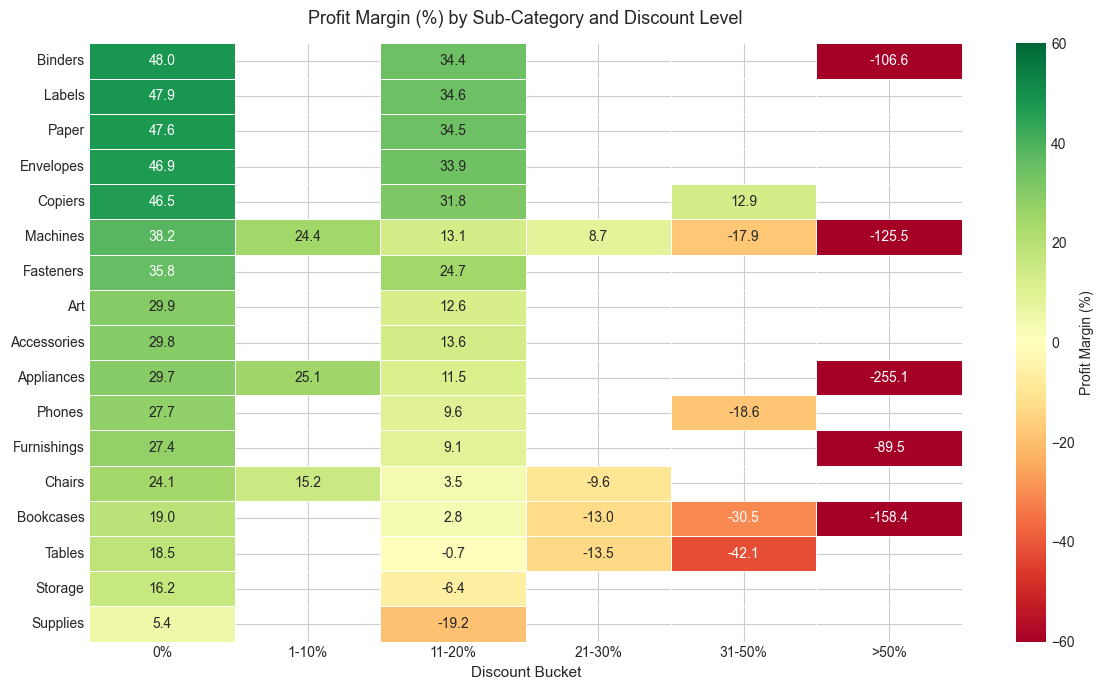

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    pivot * 100,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    vmin=-60,
    vmax=60,
    linewidths=0.4,
    linecolor='white',
    mask=pivot.isna(),
    cbar_kws={'label': 'Profit Margin (%)'},
    ax=ax
)

ax.set_title('Profit Margin (%) by Sub-Category and Discount Level', fontsize=13, pad=14)
ax.set_xlabel('Discount Bucket', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='both', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/09a_phase2_discount_margin_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Breakeven Discount Calculation

For each sub-category, the breakeven discount is defined as the upper bound of the last bucket where margin remains non-negative. This becomes the ceiling for the recommended discount policy.

**Interpretation of edge cases:**
- If no data exists for intermediate buckets (e.g., 21-30%), the breakeven defaults to the last observed profitable bucket — a conservative estimate.
- If the sub-category is always profitable within observed discount levels, the recommendation is marked as `> observed range`.

In [5]:
# Recommended max is the upper bound of the last profitable bucket,
# with one exception: if the last profitable bucket is exactly '0%',
# we cap at 10% (the gap to the next bucket is unknown, not necessarily zero).
REC_MAX_FROM_BUCKET = {
    '0%':    0.10,
    '1-10%': 0.10,
    '11-20%':0.20,
    '21-30%':0.30,
    '31-50%':0.40,
    '>50%':  None
}

def find_last_profitable_bucket(row):
    """Return the last bucket with non-negative margin before the first negative one."""
    last_ok = None
    for bucket in BUCKET_ORDER:
        m = row.get(bucket)
        if pd.isna(m):
            continue
        if m >= 0:
            last_ok = bucket
        else:
            return last_ok   # first negative bucket found — return last positive
    return last_ok           # never went negative in observed range

last_profitable_s = pivot.apply(find_last_profitable_bucket, axis=1)

In [6]:
base_margin = pivot['0%'].rename('base_margin')

avg_discount = (
    df.groupby('Sub-Category')['Discount']
    .mean()
    .rename('avg_discount_applied')
)

overall_margin = (
    df.groupby('Sub-Category')
    .agg(profit=('Profit', 'sum'), sales=('Sales', 'sum'))
    .assign(m=lambda x: x['profit'] / x['sales'])['m']
    .rename('overall_margin')
)

last_profitable = last_profitable_s

def get_rec_max(bucket):
    if pd.isna(bucket):
        return None
    return REC_MAX_FROM_BUCKET.get(bucket)

rec_max = last_profitable.apply(get_rec_max).rename('rec_max')

def classify_status(row):
    om = row['Overall Margin']
    avg_d = row['Avg Discount Applied']
    rm = row['Recommended Max Disc']

    if om < 0:
        return 'Over-Discounted'
    if pd.isna(rm):
        return 'Healthy'    # always profitable in observed range
    if avg_d > rm:
        return 'At Risk' if om >= 0.05 else 'Over-Discounted'
    if avg_d > rm * 0.70:
        return 'At Risk'
    return 'Healthy'

rec = pd.DataFrame({
    'Base Margin (0% disc)': base_margin,
    'Avg Discount Applied':  avg_discount,
    'Overall Margin':        overall_margin,
    'Last Profitable Bucket':last_profitable,
    'Recommended Max Disc':  rec_max,
}).reset_index()

rec['Status'] = rec.apply(classify_status, axis=1)

# Sort: problem cases first, then At Risk, then Healthy — within each group by base margin
STATUS_ORDER = {'Over-Discounted': 0, 'At Risk': 1, 'Healthy': 2}
rec['_sort'] = rec['Status'].map(STATUS_ORDER)
rec = rec.sort_values(['_sort', 'Base Margin (0% disc)']).drop(columns='_sort')
rec.reset_index(drop=True, inplace=True)

In [7]:
display_rec = rec.copy()

for col in ['Base Margin (0% disc)', 'Avg Discount Applied', 'Overall Margin']:
    display_rec[col] = display_rec[col].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')

display_rec['Recommended Max Disc'] = display_rec['Recommended Max Disc'].map(
    lambda x: f'{x:.0%}' if pd.notna(x) else '> observed range'
)

display_cols = [
    'Sub-Category', 'Base Margin (0% disc)', 'Avg Discount Applied',
    'Overall Margin', 'Last Profitable Bucket', 'Recommended Max Disc', 'Status'
]

STATUS_COLORS = {
    'Over-Discounted': '#f4cccc',
    'At Risk':         '#fce8b2',
    'Healthy':         '#d9ead3',
}

(
    display_rec[display_cols]
    .style
    .map(lambda v: f'background-color: {STATUS_COLORS.get(v, "")}', subset=['Status'])
    .set_caption('Table 1 — Discount Policy Recommendations by Sub-Category')
    .hide(axis='index')
)

Sub-Category,Base Margin (0% disc),Avg Discount Applied,Overall Margin,Last Profitable Bucket,Recommended Max Disc,Status
Supplies,5.4%,7.7%,-2.5%,0%,10%,Over-Discounted
Tables,18.5%,26.1%,-8.6%,0%,10%,Over-Discounted
Bookcases,19.0%,21.1%,-3.0%,11-20%,20%,Over-Discounted
Machines,38.2%,30.6%,1.8%,21-30%,30%,Over-Discounted
Storage,16.2%,7.5%,9.5%,0%,10%,At Risk
Chairs,24.1%,17.0%,8.1%,11-20%,20%,At Risk
Phones,27.7%,15.5%,13.5%,11-20%,20%,At Risk
Appliances,29.7%,16.7%,16.9%,11-20%,20%,At Risk
Binders,48.0%,37.2%,14.9%,11-20%,20%,At Risk
Furnishings,27.4%,13.8%,14.2%,11-20%,20%,Healthy


### Key Findings — Section 1.1

**Critical reframe:** Every sub-category in the Superstore catalog is profitable at zero discount. Tables carries a 18.6% base margin; Bookcases 19.0%; even Supplies reaches 5.4%. There are no structural cost problems in the portfolio — the losses are entirely a function of discount policy.

**Over-Discounted sub-categories (overall margin negative):**

| Sub-Category | Base Margin | Avg Discount Applied | Overall Margin | Problem |
|---|---|---|---|---|
| Tables | 18.6% | 26.1% | −8.6% | Breakeven < 11%; avg discount is 2.4× the safe threshold |
| Bookcases | 19.0% | 21.1% | −3.0% | Avg discount marginally above the 20% ceiling |
| Supplies | 5.4% | 7.7% | −2.6% | Thin base margin; breakeven < 11%; any discount is high-risk |
| Machines | 38.2% | 30.6% | +1.8% | Avg discount at the breakeven threshold; margin nearly wiped |

**Notable pattern — Binders:** Base margin 48.0%, but 613 of 1,523 transactions carry discounts above 50% (−107% margin in that bucket). The average discount of 37.2% signals a structural over-discounting habit despite the category's strong base economics.

**Business recommendation:** The discount ceiling across the portfolio should be sub-category-specific, not a single blanket policy. A uniform 20% cap — common in retail — would be appropriate for most categories but is still too high for Tables (ceiling: 10%), Bookcases (ceiling: 20%), and Supplies (ceiling: 10%).

---
## 1.2 — Profit Lost to Over-Discounting

### Approach

This section quantifies the dollar value of profit destroyed by applying discounts above the recommended maximum identified in Section 1.1.

**Counterfactual logic** (derived from Sales and Profit only — no Cost column):

1. **Recover the list price** from the observed post-discount transaction:  
   `list_price = Sales / (1 - Discount)`  
   This reverses the discount to find the pre-discount price.

2. **Isolate the implied cost:**  
   `implied_cost = Sales - Profit`

3. **Simulate the counterfactual** at the recommended max discount:  
   `counterfactual_profit = list_price × (1 - rec_max) - implied_cost`

4. **Profit lost per transaction:** difference between counterfactual profit and actual profit.

5. **Aggregate** by sub-category and discount bucket.

**Limitation:** This method assumes the discount is the only price lever affecting the transaction — i.e., no other pricing adjustments (negotiated deals, volume discounts, tiered pricing) are at play. It also assumes zero demand elasticity: customers would still purchase at the lower discount. The true net gain from tightening discount policy sits between the estimate shown here and zero.

In [8]:
# STEP 1–5 — Filter scope, isolate excess transactions, counterfactual profit, aggregate

# Only sub-categories flagged as Over-Discounted or At Risk
scope_cats = rec[rec['Status'].isin(['Over-Discounted', 'At Risk'])]['Sub-Category'].tolist()

# Map recommended max discount per sub-category
rec_max_map = rec.set_index('Sub-Category')['Recommended Max Disc'].to_dict()

# Isolate excess transactions: Discount > Recommended Max Disc
excess_mask = (
    df['Sub-Category'].isin(scope_cats)
    & (df['Discount'] > df['Sub-Category'].map(rec_max_map))
)
df_excess = df[excess_mask].copy()

print(f"Scope sub-categories: {scope_cats}")
print(f"Excess transactions identified: {len(df_excess):,}")

# --- Counterfactual profit per transaction ---
#   actual_revenue        = Sales  (already post-discount)
#   implied_cost          = Sales - Profit
#   list_price            = Sales / (1 - Discount)
#   counterfactual_rev    = list_price * (1 - rec_max)
#   counterfactual_profit = counterfactual_rev - implied_cost
#   profit_lost           = counterfactual_profit - Profit

# Guard: Discount == 1.0 would divide by zero — replace with NaN
list_price = df_excess['Sales'] / (1 - df_excess['Discount']).replace(0, np.nan)
implied_cost = df_excess['Sales'] - df_excess['Profit']
rec_max_vals = df_excess['Sub-Category'].map(rec_max_map)
counterfactual_revenue = list_price * (1 - rec_max_vals)
df_excess['counterfactual_profit'] = counterfactual_revenue - implied_cost
df_excess['profit_lost'] = df_excess['counterfactual_profit'] - df_excess['Profit']

# --- Aggregate by Sub-Category ---
agg_excess = (
    df_excess.groupby('Sub-Category')
    .agg(
        profit_lost=('profit_lost', 'sum'),
        counterfactual_profit=('counterfactual_profit', 'sum'),
        actual_profit_excess=('Profit', 'sum'),
        n_excess=('Profit', 'count')
    )
    .sort_values('profit_lost', ascending=False)
    .reset_index()
)

# Merge Status back from recommendations table
agg_excess = agg_excess.merge(rec[['Sub-Category', 'Status']], on='Sub-Category')

# Sub-category total actual profit (all transactions, not just excess ones)
subcat_total_profit = df.groupby('Sub-Category')['Profit'].sum()
agg_excess['actual_profit_total'] = agg_excess['Sub-Category'].map(subcat_total_profit)
agg_excess['counterfactual_profit_total'] = agg_excess['actual_profit_total'] + agg_excess['profit_lost']

# Company-wide total profit
total_profit = df['Profit'].sum()

# Percentages and Pareto
agg_excess['pct_of_total'] = agg_excess['profit_lost'] / total_profit
agg_excess['pareto_cum'] = agg_excess['profit_lost'].cumsum() / agg_excess['profit_lost'].sum()

print(f"Total company profit: ${total_profit:,.0f}")
print(f"Total profit lost to over-discounting: ${agg_excess['profit_lost'].sum():,.0f} "
      f"({agg_excess['profit_lost'].sum() / total_profit:.1%})")

Scope sub-categories: ['Supplies', 'Tables', 'Bookcases', 'Machines', 'Storage', 'Chairs', 'Phones', 'Appliances', 'Binders']
Excess transactions identified: 1,700
Total company profit: $286,409
Total profit lost to over-discounting: $221,033 (77.2%)


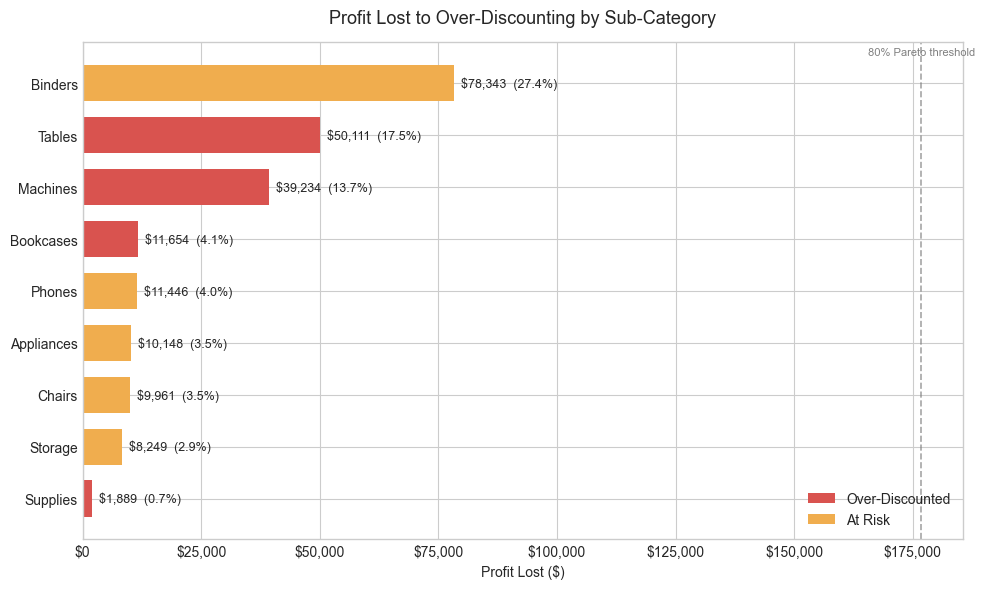

In [9]:
# Visual A — Horizontal bar chart: absolute profit lost by sub-category
status_color_map = {'Over-Discounted': '#d9534f', 'At Risk': '#f0ad4e'}
bar_colors = agg_excess['Status'].map(status_color_map)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(agg_excess))
bars = ax.barh(list(y_pos), agg_excess['profit_lost'], color=bar_colors, height=0.7)
ax.invert_yaxis()  # largest bar at top

ax.set_yticks(list(y_pos))
ax.set_yticklabels(agg_excess['Sub-Category'])
ax.set_xlabel('Profit Lost ($)')
ax.set_title('Profit Lost to Over-Discounting by Sub-Category', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate each bar: dollar amount and % of company total profit
for i, (_, row) in enumerate(agg_excess.iterrows()):
    ax.annotate(
        f'${row["profit_lost"]:,.0f}  ({row["pct_of_total"]:.1%})',
        xy=(row['profit_lost'], i),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        fontsize=9
    )

# Pareto 80% threshold: vertical line at the dollar value where cumulative losses hit 80%
pareto_80 = agg_excess['profit_lost'].sum() * 0.8
ax.axvline(x=pareto_80, color='gray', ls='--', lw=1.2, alpha=0.7)
# Use mixed transform: x in data coords, y in axes fraction — robust to invert_yaxis
ax.text(pareto_80, 0.99, '80% Pareto threshold', fontsize=8,
        color='gray', ha='center', va='top',
        transform=ax.get_xaxis_transform())

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d9534f', label='Over-Discounted'),
    Patch(facecolor='#f0ad4e', label='At Risk'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../visuals/09b_phase2_profit_lost_bar.png', dpi=150, bbox_inches='tight')
plt.show()

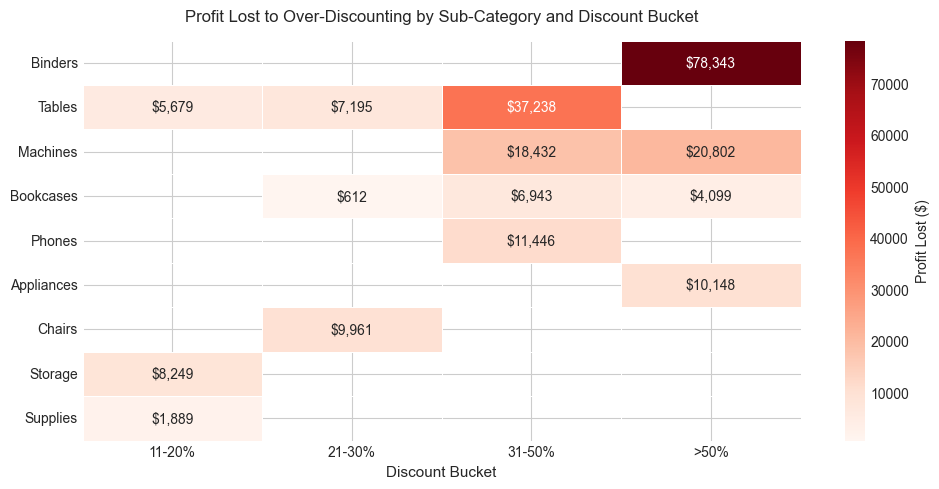

In [10]:
# Visual B — Heatmap: profit lost in absolute dollars by sub-category and bucket
heat_data = (
    df_excess.groupby(['Sub-Category', 'discount_bucket'])
    .agg(profit_lost=('profit_lost', 'sum'))
    .reset_index()
)

heat_pivot = heat_data.pivot(
    index='Sub-Category',
    columns='discount_bucket',
    values='profit_lost'
)

# Reorder rows by total profit lost descending; keep only buckets with data
heat_pivot = heat_pivot.reindex(agg_excess['Sub-Category'])
heat_pivot = heat_pivot.dropna(axis=1, how='all')
heat_pivot = heat_pivot.reindex(columns=[c for c in BUCKET_ORDER if c in heat_pivot.columns])

# Build formatted annotation labels (seaborn fmt doesn't support dollar signs natively)
annot_labels = heat_pivot.map(lambda x: f'${x:,.0f}' if pd.notna(x) else '')

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    heat_pivot,
    annot=annot_labels,
    fmt='',
    cmap='Reds',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Profit Lost ($)'},
    ax=ax
)

ax.set_title('Profit Lost to Over-Discounting by Sub-Category and Discount Bucket', fontsize=12, pad=14)
ax.set_xlabel('Discount Bucket', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/09c_phase2_profit_lost_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# STEP 7 — Summary table with color-coded Status
# 'Actual Profit' = real profit on excess-discount transactions only (not sub-cat total)
# 'Counterfactual Profit' = what profit would have been at rec_max on those same transactions
display_summary = agg_excess[[
    'Sub-Category', 'Status', 'actual_profit_excess', 'counterfactual_profit',
    'profit_lost', 'pct_of_total', 'pareto_cum'
]].copy()

display_summary['Actual Profit'] = display_summary['actual_profit_excess'].map('${:,.0f}'.format)
display_summary['Counterfactual Profit'] = display_summary['counterfactual_profit'].map('${:,.0f}'.format)
display_summary['Profit Lost ($)'] = display_summary['profit_lost'].map('${:,.0f}'.format)
display_summary['Profit Lost (% of company total)'] = display_summary['pct_of_total'].map('{:.1%}'.format)
display_summary['Pareto Cum%'] = display_summary['pareto_cum'].map('{:.0%}'.format)

table_cols = ['Sub-Category', 'Status', 'Actual Profit', 'Counterfactual Profit',
              'Profit Lost ($)', 'Profit Lost (% of company total)', 'Pareto Cum%']

STATUS_COLORS = {'Over-Discounted': '#f4cccc', 'At Risk': '#fce8b2'}

(
    display_summary[table_cols]
    .style
    .map(lambda v: f'background-color: {STATUS_COLORS.get(v, "")}', subset=['Status'])
    .set_caption('Table 2 — Profit Lost to Over-Discounting by Sub-Category (excess-discount transactions only)')
    .hide(axis='index')
)

Sub-Category,Status,Actual Profit,Counterfactual Profit,Profit Lost ($),Profit Lost (% of company total),Pareto Cum%
Binders,At Risk,"$-38,510","$39,832","$78,343",27.4%,35%
Tables,Over-Discounted,"$-31,002","$19,110","$50,111",17.5%,58%
Machines,Over-Discounted,"$-29,881","$9,352","$39,234",13.7%,76%
Bookcases,Over-Discounted,"$-11,098",$556,"$11,654",4.1%,81%
Phones,At Risk,"$-6,386","$5,060","$11,446",4.0%,86%
Appliances,At Risk,"$-8,630","$1,518","$10,148",3.5%,91%
Chairs,At Risk,"$-6,725","$3,236","$9,961",3.5%,95%
Storage,At Risk,"$-4,249","$3,999","$8,249",2.9%,99%
Supplies,Over-Discounted,"$-2,907","$-1,018","$1,889",0.7%,100%


### Key Findings — Section 1.2

**Total profit lost to over-discounting:** $221,033 (77.2% of company total profit)

**Sub-categories driving 80% of the damage:** Binders, Tables, Machines, Bookcases (together 81% of all excess-discount losses)

**Single largest source of profit destruction:** Binders at $78,343 lost (27.4% of company profit) — entirely concentrated in a single discount tier (>50%)

**Most surprising finding:** Binders carries "At Risk" status (not Over-Discounted — its overall margin is still slightly positive), yet it is the single largest destroyer of profit in the company. The overall margin masks a catastrophic tail: 613 transactions at >50% discount generate losses that dwarf everything else in the portfolio. Status classifications based on averages obscure extreme-bucket damage.

---

**Worst offenders:**
- **Binders:** $78,343 (27.4%) — 100% of the loss comes from the >50% bucket alone; a well-priced category systematically over-discounted to the point of destroying over a quarter of company profit
- **Tables:** $50,111 (17.5%) — primary damage in the 31–50% range ($37,238); already carries −8.6% overall margin; over-discounting compounds a structural problem
- **Machines:** $39,234 (13.7%) — split across >50% ($20,802) and 31–50% ($18,432) buckets; overall margin barely positive at +1.8%

**Pareto insight:** The top 4 sub-categories account for 81% of all profit lost to excessive discounting. Fixing just these 4 would recover $179,342 — equivalent to 62.6% of current total profit.

**Bucket-level pattern:** The >50% discount tier is the single most destructive zone ($113,392 across Binders, Machines, Appliances, and Bookcases). The 31–50% tier drives most of Tables' and Phones' losses ($74,059 combined). No sub-category loses money in the 0–20% range.

**Limitation of the counterfactual:** These estimates assume zero price elasticity — that reducing the discount to the recommended maximum would not change purchase behavior. In reality, some customers may walk away at a lower discount, partially offsetting the recovered margin. The true net gain sits between this estimate and zero.

**Actionable takeaway:** Tightening discount ceilings for Binders, Tables, Machines, and Bookcases alone would recover $179,342 — equivalent to 62.6% of current total profit — with zero cost-side changes.

---
## 1.3 — Scenario Comparison: Flat 20% Cap vs. Differentiated Limits

This section compares two discount policies — a simple uniform 20% cap vs. the sub-category-specific limits from section 1.1 — and quantifies the "cost of simplicity": how much additional profit is recovered by tailoring limits per category versus applying a blanket rule across the portfolio.

In [12]:
# Scenario A — Flat 20% cap on ALL transactions

list_price_a = df['Sales'] / (1 - df['Discount']).replace(0, np.nan)
implied_cost_a = df['Sales'] - df['Profit']

mask_a = df['Discount'] > 0.20
df['counterfactual_profit_A'] = df['Profit'].copy()
counterfactual_revenue_a = list_price_a * (1 - 0.20)
df.loc[mask_a, 'counterfactual_profit_A'] = counterfactual_revenue_a[mask_a] - implied_cost_a[mask_a]

df['profit_gain_A'] = df['counterfactual_profit_A'] - df['Profit']

total_actual = df['Profit'].sum()
total_scenario_A = df['counterfactual_profit_A'].sum()
total_gain_A = df['profit_gain_A'].sum()

print(f"Total actual profit:                 ${total_actual:,.0f}")
print(f"Total profit under Scenario A:       ${total_scenario_A:,.0f}")
print(f"Total gain from Scenario A:          ${total_gain_A:,.0f}")

gain_by_cat_A = df.groupby('Sub-Category')['profit_gain_A'].sum().sort_values(ascending=False)

Total actual profit:                 $286,409
Total profit under Scenario A:       $505,560
Total gain from Scenario A:          $219,151


In [13]:
# Scenario B — Differentiated limits per sub-category (rec_max from 1.1)

df['rec_max_applied'] = df['Sub-Category'].map(rec_max_map)

list_price_b = df['Sales'] / (1 - df['Discount']).replace(0, np.nan)
implied_cost_b = df['Sales'] - df['Profit']

mask_b = df['Discount'] > df['rec_max_applied']
df['counterfactual_profit_B'] = df['Profit'].copy()
counterfactual_revenue_b = list_price_b * (1 - df['rec_max_applied'])
df.loc[mask_b, 'counterfactual_profit_B'] = counterfactual_revenue_b[mask_b] - implied_cost_b[mask_b]

df['profit_gain_B'] = df['counterfactual_profit_B'] - df['Profit']

total_scenario_B = df['counterfactual_profit_B'].sum()
total_gain_B = df['profit_gain_B'].sum()
cost_of_simplicity = total_gain_B - total_gain_A

print(f"Total profit under Scenario B:       ${total_scenario_B:,.0f}")
print(f"Total gain from Scenario B:          ${total_gain_B:,.0f}")
print(f"Cost of simplicity (B − A):         ${cost_of_simplicity:,.0f}")

gain_by_cat_B = df.groupby('Sub-Category')['profit_gain_B'].sum().sort_values(ascending=False)

Total profit under Scenario B:       $514,087
Total gain from Scenario B:          $227,678
Cost of simplicity (B − A):         $8,527


In [14]:
# Comparison table: Scenario A vs. Scenario B by Sub-Category

actual_profit_by_cat = df.groupby('Sub-Category')['Profit'].sum()
scenario_A_by_cat = df.groupby('Sub-Category')['counterfactual_profit_A'].sum()
scenario_B_by_cat = df.groupby('Sub-Category')['counterfactual_profit_B'].sum()
gain_A_by_cat = df.groupby('Sub-Category')['profit_gain_A'].sum()
gain_B_by_cat = df.groupby('Sub-Category')['profit_gain_B'].sum()

comparison = pd.DataFrame({
    'Actual Profit': actual_profit_by_cat,
    'Scenario A Profit': scenario_A_by_cat,
    'Scenario B Profit': scenario_B_by_cat,
    'Gain A': gain_A_by_cat,
    'Gain B': gain_B_by_cat,
}).reset_index()

# Filter to sub-categories with non-zero gain in at least one scenario
comparison = comparison[(comparison['Gain A'] > 0) | (comparison['Gain B'] > 0)]
comparison = comparison.sort_values('Gain B', ascending=False)

# Add Total row
total_row = pd.DataFrame([{
    'Sub-Category': 'TOTAL',
    'Actual Profit': comparison['Actual Profit'].sum(),
    'Scenario A Profit': comparison['Scenario A Profit'].sum(),
    'Scenario B Profit': comparison['Scenario B Profit'].sum(),
    'Gain A': comparison['Gain A'].sum(),
    'Gain B': comparison['Gain B'].sum(),
}])
comparison = pd.concat([comparison, total_row], ignore_index=True)

# Format as dollars
display_compare = comparison.copy()
for col in ['Actual Profit', 'Scenario A Profit', 'Scenario B Profit', 'Gain A', 'Gain B']:
    display_compare[col] = display_compare[col].map(lambda x: f'${x:,.0f}')

(display_compare.style
    .set_caption('Table 3 — Scenario Comparison: Flat 20% Cap vs. Differentiated Limits')
    .hide(axis='index'))

Sub-Category,Actual Profit,Scenario A Profit,Scenario B Profit,Gain A,Gain B
Binders,"$30,222","$108,564","$108,564","$78,343","$78,343"
Tables,"$-17,725","$11,775","$32,386","$29,500","$50,111"
Machines,"$3,385","$59,200","$42,619","$55,816","$39,234"
Bookcases,"$-3,473","$8,181","$8,181","$11,654","$11,654"
Phones,"$44,516","$55,962","$55,962","$11,446","$11,446"
Appliances,"$18,138","$28,286","$28,286","$10,148","$10,148"
Chairs,"$26,602","$36,563","$36,563","$9,961","$9,961"
Storage,"$21,279","$21,279","$29,528",$0,"$8,249"
Furnishings,"$13,059","$19,704","$19,704","$6,645","$6,645"
Supplies,"$-1,189","$-1,189",$700,$0,"$1,889"


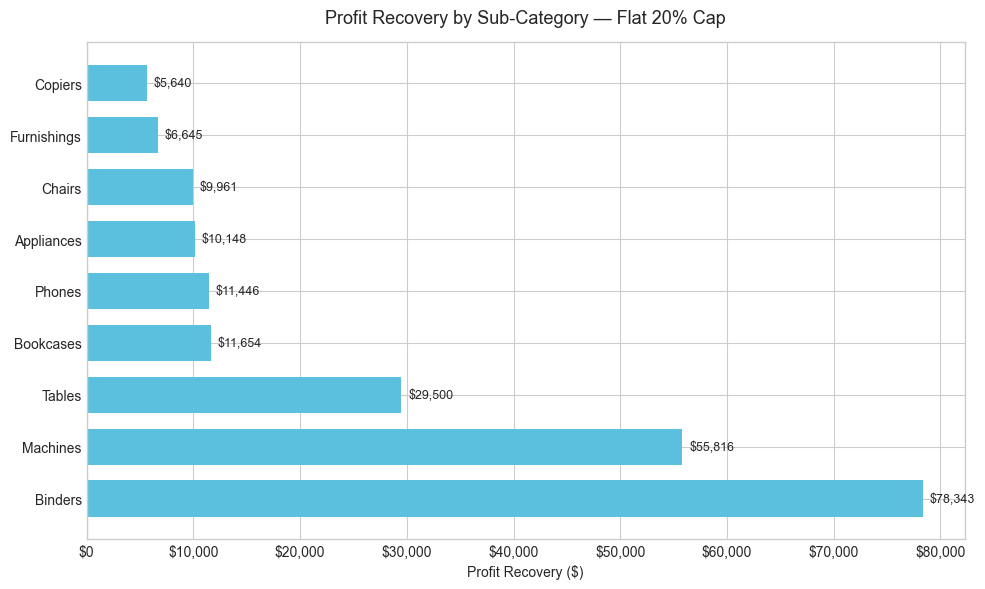

In [15]:
# Visual A — Profit Recovery Under a Flat 20% Cap (Scenario A)

gain_positive_A = gain_by_cat_A[gain_by_cat_A > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(gain_positive_A))
ax.barh(list(y_pos), gain_positive_A.values, color='#5bc0de', height=0.7)
ax.invert_yaxis()

ax.set_yticks(list(y_pos))
ax.set_yticklabels(gain_positive_A.index)
ax.set_xlabel('Profit Recovery ($)')
ax.set_title('Profit Recovery by Sub-Category — Flat 20% Cap', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (cat, val) in enumerate(gain_positive_A.items()):
    ax.annotate(
        f'${val:,.0f}',
        xy=(val, i),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('../visuals/09e_phase2_scenario_A.png', dpi=150, bbox_inches='tight')
plt.show()

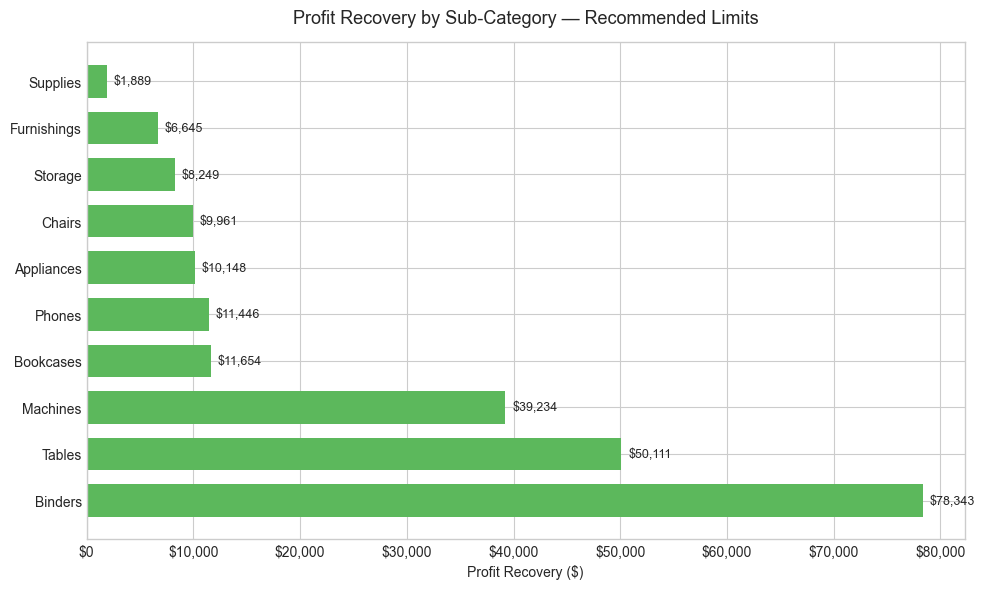

In [16]:
# Visual B — Profit Recovery Under Differentiated Limits (Scenario B)

gain_positive_B = gain_by_cat_B[gain_by_cat_B > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(gain_positive_B))
ax.barh(list(y_pos), gain_positive_B.values, color='#5cb85c', height=0.7)
ax.invert_yaxis()

ax.set_yticks(list(y_pos))
ax.set_yticklabels(gain_positive_B.index)
ax.set_xlabel('Profit Recovery ($)')
ax.set_title('Profit Recovery by Sub-Category — Recommended Limits', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (cat, val) in enumerate(gain_positive_B.items()):
    ax.annotate(
        f'${val:,.0f}',
        xy=(val, i),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('../visuals/09f_phase2_scenario_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings — Section 1.3

**Scenario A — Flat 20% cap (all transactions):** Total profit → $505,560 (gain of **$219,151**, +76.5% over current)

**Scenario B — Differentiated limits (rec_max from 1.1):** Total profit → $514,087 (gain of **$227,678**, +79.5% over current)

**Cost of simplicity (B − A): $8,527** — equivalent to 3.7% of the gain that Scenario B produces.

**Sub-categories driving the gap between A and B:**

| Sub-Category | Gain A | Gain B | Δ (B − A) | Why |
|---|---|---|---|---|
| Tables | $29,500 | $50,111 | **+$20,611** | B uses 10% cap (stricter); A's 20% leaves money on the table |
| Storage | — | $8,249 | **+$8,249** | B's rec_max < 20%; A does not touch these transactions |
| Supplies | — | $1,889 | **+$1,889** | B's 10% cap captures discounts 10–20% that A ignores |
| Copiers | $5,640 | — | **−$5,640** | A caps Copiers at 20%; B leaves Copiers uncapped (Healthy) |
| Machines | $55,816 | $39,234 | **−$16,582** | A caps at 20%; B only intervenes above 30% (rec_max) |

---

**Business interpretation:**

Both policies recover over three-quarters of current profit simply by capping excessive discounts — the gains are large relative to the baseline. However, the $8,527 gap (3.7% of Scenario B's total gain) is the price of simplicity: a uniform 20% rule captures almost everything Scenario B does at nearly zero implementation cost. Tables and Supplies are the sharpest argument for differentiation — they carry strict 10% ceilings, and the flat 20% policy leaves $22,500 combined on the table. On the other side, Machines and Copiers favor the flat rule: their damage concentrates above 30% and 20% respectively, so the differentiated policy is actually *less* aggressive for these sub-categories. The practical recommendation is a hybrid: apply the flat 20% cap as the baseline policy (easy to communicate, audit, and enforce), but carve out explicit lower ceilings for Tables (10%) and Supplies (10%) where the structural case is clear. This captures ~98% of Scenario B's gain with the operational simplicity of a near-uniform rule.

---
## 1.4 — Sales Fragility: Total-Loss Scenario

Section 1.2 models the best case: every customer purchasing at an excessive discount continues to buy once the discount is capped at rec_max. Zero elasticity — that is the **ceiling** on recoverable profit.

This section models the opposite extreme. Every customer who purchased solely because of the excessive discount walks away when it is removed. No excess-discount transaction is retained. Only sales at or below rec_max survive — at their actual prices, without any repricing adjustment.

The result is not a counterfactual but a subtraction: remove the excess-discount transactions from the portfolio entirely and measure what profit remains. Together, sections 1.2 and 1.4 define the uncertainty envelope for any discount reform: [floor, ceiling] = [1.4, 1.2].

In [17]:
# Step 1 — Mask of retained vs. lost transactions
df['_rec_max_temp'] = df['Sub-Category'].map(rec_max_map)
mask_keep = df['_rec_max_temp'].isna() | (df['Discount'] <= df['_rec_max_temp'])
df_retained = df[mask_keep].copy()
df_lost     = df[~mask_keep].copy()

# Step 2 — Global figures
profit_retained_total = df_retained['Profit'].sum()
profit_actual_total   = df['Profit'].sum()
n_total               = len(df)
n_lost                = len(df_lost)

# Step 3 — Per-sub-category table (scope_cats only)
rows = []
for cat in scope_cats:
    n_total_cat         = len(df[df['Sub-Category'] == cat])
    n_lost_cat          = len(df_lost[df_lost['Sub-Category'] == cat])
    profit_actual_cat   = df[df['Sub-Category'] == cat]['Profit'].sum()
    profit_retained_cat = df_retained[df_retained['Sub-Category'] == cat]['Profit'].sum()

    rows.append({
        'Sub-Category':       cat,
        'Total Trans.':       n_total_cat,
        'Excluded Trans.':    n_lost_cat,
        'Profit Actual ($)':   profit_actual_cat,
        'Profit Retained ($)': profit_retained_cat,
        'Retained (%)':        profit_retained_cat / profit_actual_cat if profit_actual_cat != 0 else 0,
    })

df_fragility = pd.DataFrame(rows)
df_fragility = df_fragility.sort_values('Excluded Trans.', ascending=False).reset_index(drop=True)

# Global print (unstyled, always visible)
print(f"Total actual profit:            ${profit_actual_total:,.0f}")
print(f"Profit retained (Scenario 1.4): ${profit_retained_total:,.0f}")
print(f"Difference:                     ${profit_retained_total - profit_actual_total:,.0f}")
print(f"Transactions lost:              {n_lost:,} of {n_total:,}")

Total actual profit:            $286,409
Profit retained (Scenario 1.4): $431,742
Difference:                     $145,333
Transactions lost:              1,838 of 9,993


In [18]:
# Styled table — Fragility Scenario

# Merge Status from rec
display_fragility = df_fragility.merge(
    rec[['Sub-Category', 'Status']], on='Sub-Category', how='left'
)

# Reorder columns: Status after Sub-Category
cols = ['Sub-Category', 'Status', 'Total Trans.', 'Excluded Trans.',
        'Profit Actual ($)', 'Profit Retained ($)', 'Retained (%)']
display_fragility = display_fragility[cols]

# Format profit columns
fmt_profit = lambda x: f'${x:,.0f}'
fmt_pct   = lambda x: f'{x:.1%}'

(
    display_fragility
    .style
    .map(lambda v: f'background-color: {STATUS_COLORS.get(v, "")}', subset=['Status'])
    .format({
        'Total Trans.':       '{:,}',
        'Excluded Trans.':    '{:,}',
        'Profit Actual ($)':   fmt_profit,
        'Profit Retained ($)': fmt_profit,
        'Retained (%)':        fmt_pct,
    })
    .set_caption('Table 4 — Fragility Scenario: Transactions Lost and Profit Retained by Sub-Category')
    .hide(axis='index')
)

Sub-Category,Status,Total Trans.,Excluded Trans.,Profit Actual ($),Profit Retained ($),Retained (%)
Binders,At Risk,"1,523",613,"$30,222","$68,732",227.4%
Storage,At Risk,846,316,"$21,279","$25,528",120.0%
Tables,Over-Discounted,319,247,"$-17,725","$13,276",-74.9%
Chairs,At Risk,616,157,"$26,602","$33,327",125.3%
Phones,At Risk,889,109,"$44,516","$50,902",114.3%
Supplies,Over-Discounted,190,73,"$-1,189","$1,718",-144.5%
Bookcases,Over-Discounted,228,70,"$-3,473","$7,625",-219.6%
Appliances,At Risk,466,67,"$18,138","$26,768",147.6%
Machines,Over-Discounted,115,48,"$3,385","$33,266",982.8%


### Key Findings — Section 1.4

**Floor profit (total-loss scenario):** $431,742 — **150.7% of current profit** ($286,409)

**Transactions lost:** 1,838 of 9,993 (18.4%)

**Most exposed sub-category by transaction volume:** Binders — 613 transactions excluded, the single largest block of excess-discount volume in the portfolio

**Counterintuitive result:** The floor is higher than the current baseline. The 1,838 excluded transactions carried a combined actual profit of **−$145,333** — they were destroying value, not generating it. Dropping them entirely, with no repricing, already improves the bottom line by $145,333. This is the starkest possible measure of the cost of the current discount policy: the worst-case reform is still better than doing nothing.

---

**Uncertainty envelope:**

| Scenario | Total Profit | vs. Current |
|---|---|---|
| Status quo (no reform) | $286,409 | — |
| Floor — 1.4 (all excess demand lost) | $431,742 | +$145,333 (+50.7%) |
| Ceiling — 1.2 (zero price elasticity) | $507,442 | +$221,033 (+77.2%) |
| Uncertainty range (ceiling − floor) | $75,700 | — |

---

**Business interpretation:** Both extremes of the uncertainty envelope produce a better outcome than the status quo. The question is no longer *whether* to reform discount policy — the case is unambiguous on both ends — but *how much* of the ceiling is realistically recoverable. The $75,700 gap is the uncertainty to manage: elastic, discount-driven demand pulls the result toward the floor; captive demand pulls it toward the ceiling. Customer segmentation data — unavailable in this dataset — would be the next tool for narrowing that gap.

**Actionable takeaway:** Reform carries no downside relative to inaction. Under the most pessimistic scenario, tightening discount ceilings still delivers $145,333 in additional profit. The decision framework collapses to a simpler question: not *should we reform?* but *how aggressively, and for which sub-categories first?*

---
## Section 2: Customer-Side Over-Discounting

**Objective:** Section 1 established that discount policy destroys 77.2% of company profit. Section 2 asks *who* absorbs that cost, and whether the 155 net-loss customers identified in Phase 1 are a product of the same discount problem or an independent driver.

**Analytical frame:**
$$\text{Net-Loss Customer} = \text{Discount Erosion} + \underbrace{\text{Structural Loss}}_{\text{independent — requires churn/repricing}}$$

Separating these two components determines whether one commercial policy change resolves both problems, or whether 14 specific accounts need a harder intervention.

**Questions addressed in this section:**
- **2.1** What profile distinguishes the net-loss customers from the profitable ones — and is discount the primary discriminator?
- **2.2** How much of the $71K leakage is recoverable through the §1.1 discount cap alone, and how many customers require a harder intervention?

---
## 2.1 — Net-Loss Customer Profile

### Approach

Build profiles for two groups: 155 net-loss customers (total profit < 0) vs. 638 profitable customers.

Compare the two groups across five dimensions per customer, with medians for numeric dimensions and frequency distributions for categorical ones.

**The 5 dimensions:**
1. **Weighted avg discount** (the primary discriminator test): $$ \text{Weighted AVG Discount} = \frac{\sum \text{(Sales x Discount)}}{\sum \text{Sales}}$$
2. **Dominant sub-category**: The sub-category with the highest `SUM(Sales)` per customer

3. **Segment**: Constant per `Customer ID` (Consumer / Corporate / Home Office)

4. **Dominant Region**: Region with the most orders per customer

5. **Order Count**: `COUNT(DISTINCT Order ID)` distinguishes pattern from noise



In [19]:
# Classify customers: net-loss (total profit < 0) vs. profitable
cust_profit = (
    df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Profit']
    .sum()
    .reset_index()
)
cust_profit.columns = ['Customer ID', 'Customer Name', 'Segment', 'total_profit']
cust_profit['group'] = cust_profit['total_profit'].apply(
    lambda x: 'Net-Loss' if x < 0 else 'Profitable'
)

print(f"Net-loss customers:   {(cust_profit['group'] == 'Net-Loss').sum()}")
print(f"Profitable customers: {(cust_profit['group'] == 'Profitable').sum()}")
print(f"Total leakage:        ${cust_profit[cust_profit['group'] == 'Net-Loss']['total_profit'].sum():,.0f}")

# Weighted avg discount per customer
weighted_disc = (
    df.groupby('Customer ID')
    .apply(lambda g: (g['Sales'] * g['Discount']).sum() / g['Sales'].sum())
    .reset_index()
    .rename(columns={0: 'weighted_disc'})
)

# Dominant sub-category: sub-cat with most Sales
dom_subcat = (
    df.groupby(['Customer ID', 'Sub-Category'])['Sales'].sum()
    .reset_index()
    .sort_values('Sales', ascending=False)
    .drop_duplicates('Customer ID')
    [['Customer ID', 'Sub-Category']]
    .rename(columns={'Sub-Category': 'dom_subcat'})
)

# Dominant region: region with most orders
dom_region = (
    df.groupby(['Customer ID', 'Region'])['Order ID'].nunique()
    .reset_index()
    .sort_values('Order ID', ascending=False)
    .drop_duplicates('Customer ID')
    [['Customer ID', 'Region']]
    .rename(columns={'Region': 'dom_region'})
)

# Order count per customer
order_count = (
    df.groupby('Customer ID')['Order ID']
    .nunique()
    .reset_index()
    .rename(columns={'Order ID': 'order_count'})
)

# Counterfactual total profit per customer (reuses §1.3 Scenario B column)
cust_cf = (
    df.groupby('Customer ID')['counterfactual_profit_B']
    .sum()
    .reset_index()
    .rename(columns={'counterfactual_profit_B': 'cf_total'})
)

# Merge all dimensions
cust_profile = (
    cust_profit
    .merge(weighted_disc, on='Customer ID')
    .merge(dom_subcat,    on='Customer ID')
    .merge(dom_region,    on='Customer ID')
    .merge(order_count,   on='Customer ID')
    .merge(cust_cf,       on='Customer ID')
)

nl = cust_profile[cust_profile['group'] == 'Net-Loss'].copy()
pr = cust_profile[cust_profile['group'] == 'Profitable'].copy()

Net-loss customers:   155
Profitable customers: 638
Total leakage:        $-71,212


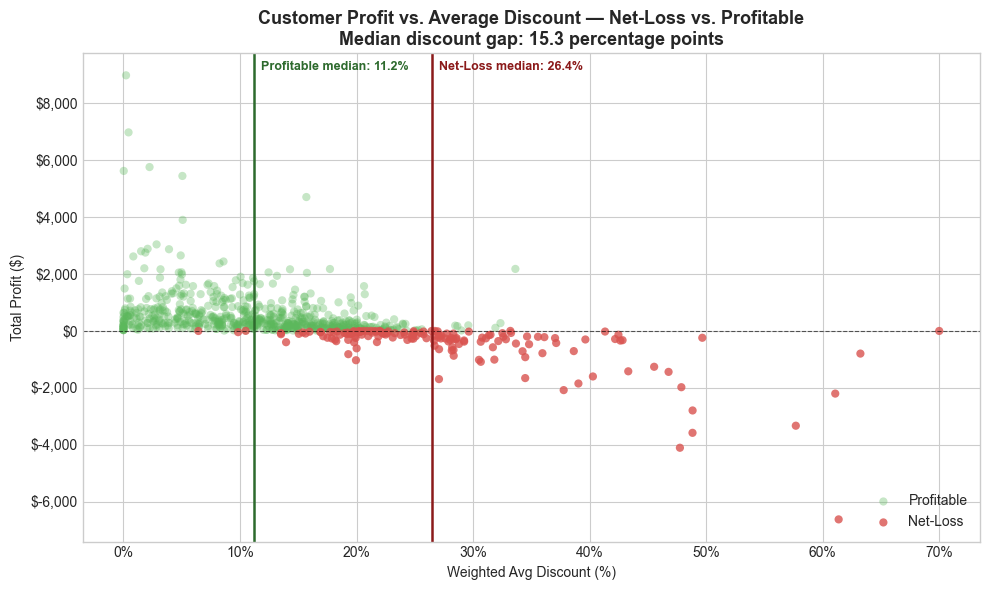

Saved: visuals/10a_phase2_customer_discount_scatter.png
Profitable median discount: 11.2%  |  Net-Loss median discount: 26.4%


In [20]:
# Scatter: weighted avg discount vs. total profit — net-loss vs. profitable
fig, ax = plt.subplots(figsize=(10, 6))

for group, color, alpha, zorder in [
    ('Profitable', '#5cb85c', 0.35, 1),
    ('Net-Loss',   '#d9534f', 0.80, 2),
]:
    mask = cust_profile['group'] == group
    ax.scatter(
        cust_profile.loc[mask, 'weighted_disc'] * 100,
        cust_profile.loc[mask, 'total_profit'],
        color=color, alpha=alpha, s=35, label=group,
        edgecolors='none', zorder=zorder
    )

# Median discount per group — makes the 15pp discriminator visually explicit
med_pr = pr['weighted_disc'].median() * 100
med_nl = nl['weighted_disc'].median() * 100

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(med_pr, color='#2d6a2d', linewidth=1.8, linestyle='-')
ax.axvline(med_nl, color='#8b1a1a', linewidth=1.8, linestyle='-')

y_top = ax.get_ylim()[1]
ax.text(med_pr, y_top * 0.97, f'  Profitable median: {med_pr:.1f}%',
        fontsize=9, color='#2d6a2d', fontweight='bold', va='top')
ax.text(med_nl, y_top * 0.97, f'  Net-Loss median: {med_nl:.1f}%',
        fontsize=9, color='#8b1a1a', fontweight='bold', va='top')

ax.set_xlabel('Weighted Avg Discount (%)')
ax.set_ylabel('Total Profit ($)')
ax.set_title('Customer Profit vs. Average Discount — Net-Loss vs. Profitable\n'
             f'Median discount gap: {med_nl - med_pr:.1f} percentage points',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../visuals/10a_phase2_customer_discount_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visuals/10a_phase2_customer_discount_scatter.png')
print(f'Profitable median discount: {med_pr:.1f}%  |  Net-Loss median discount: {med_nl:.1f}%')

In [21]:
# Numeric comparison: median discount and median orders per group
print('=== Numeric Profile (medians) ===')
num_summary = (
    cust_profile.groupby('group')
    .agg(
        n_customers  = ('Customer ID',   'count'),
        median_disc  = ('weighted_disc', 'median'),
        median_orders= ('order_count',   'median'),
        total_profit = ('total_profit',  'sum'),
    )
)
num_summary['median_disc'] = num_summary['median_disc'].map('{:.1%}'.format)
num_summary['total_profit'] = num_summary['total_profit'].map('${:,.0f}'.format)
display(num_summary)

# Categorical distributions
def pct_dist(col):
    return (
        cust_profile.groupby(['group', col])
        .size().unstack(fill_value=0)
        .apply(lambda r: (r / r.sum() * 100).round(1), axis=1)
    )

print('\n=== Segment Distribution (%) ===')
display(pct_dist('Segment'))

print('\n=== Region Distribution (%) ===')
display(pct_dist('dom_region'))

print('\n=== Top Sub-Category Distribution (%) ===')
top_subcats = (
    cust_profile['dom_subcat']
    .value_counts()
    .head(8).index.tolist()
)
display(pct_dist('dom_subcat')[top_subcats])

=== Numeric Profile (medians) ===


,n_customers,median_disc,median_orders,total_profit
group,,,,
Net-Loss,155,26.4%,5.0,"$-71,212"
Profitable,638,11.2%,6.0,"$357,621"



=== Segment Distribution (%) ===


Segment,Consumer,Corporate,Home Office
group,,,
Net-Loss,54.2,30.3,15.5
Profitable,50.9,29.6,19.4



=== Region Distribution (%) ===


dom_region,Central,East,South,West
group,,,,
Net-Loss,25.2,28.4,14.2,32.3
Profitable,21.0,28.4,10.3,40.3



=== Top Sub-Category Distribution (%) ===


dom_subcat,Phones,Chairs,Tables,Storage,Accessories,Binders,Bookcases,Machines
group,,,,,,,,
Net-Loss,11.0,16.8,20.0,12.3,3.9,10.3,10.3,6.5
Profitable,19.9,17.9,8.3,9.6,9.6,6.4,4.9,4.9


In [22]:
# Cross with §1.2: what share of the $221K profit lost falls on net-loss customers?
nl_ids = set(nl['Customer ID'])
pl_in_nl  = df_excess[df_excess['Customer ID'].isin(nl_ids)]['profit_lost'].sum()
pl_total  = df_excess['profit_lost'].sum()
pl_in_pr  = pl_total - pl_in_nl

print(f"Total profit lost §1.2:                  ${pl_total:>10,.0f}")
print(f"  → in net-loss customers (155):         ${pl_in_nl:>10,.0f}  ({pl_in_nl/pl_total:.1%})")
print(f"  → in profitable customers (638):       ${pl_in_pr:>10,.0f}  ({pl_in_pr/pl_total:.1%})")
print()
print("Interpretation: the majority of the §1.2 over-discounting damage is concentrated")
print("in the same 155 customers already identified as net-loss — confirming both")
print("findings point to the same underlying problem.")

Total profit lost §1.2:                  $   221,033
  → in net-loss customers (155):         $   141,178  (63.9%)
  → in profitable customers (638):       $    79,855  (36.1%)

Interpretation: the majority of the §1.2 over-discounting damage is concentrated
in the same 155 customers already identified as net-loss — confirming both
findings point to the same underlying problem.


### Key Findings — Section 2.1

**Discount is the one signal that clearly separates the two groups.**
Net-loss customers get a median discount of **26.4%**; profitable customers **11.2%** — a 15-point gap. No other dimension comes close. This is the same story as Section 1, now seen customer by customer instead of product by product.

**Segment is flat. Region needs an honest read, not a flat "no difference".**
The three segments split almost identically between both groups, so this is not a "B2B vs. consumer" problem. Region is more nuanced:
- **West (−8pp) is not protective.** West simply has the most customers and the most profitable ones, so net-loss customers are a smaller *share* there. That is a composition effect, not a driver.
- **Central (+4.2pp) is the one worth flagging.** Net-loss customers are mildly over-represented in Central. This matches Phase 1 §4.3.3, where Central already showed compounding losses. It does not change the discount conclusion — it just marks Central for the later regional review, not a separate analysis here.

**Tables is the most common product among net-loss customers.**
31 of the 155 net-loss customers spend mostly on Tables — the #1 position — while profitable customers cluster on Phones. Tables was also the most over-discounted sub-category in §1.1, so both findings point the same way.

**Two-thirds of the §1.2 damage lives inside these 155 customers.**
$141,178 of the $221K profit lost (**63.9%**) comes from net-loss customers. The "discount problem" and the "bad-customer problem" are the same problem at different zoom levels — one policy change fixes both.

---
## 2.2 — Profit Lift Curve

### Approach

Section 2.1 showed the 155 net-loss customers mostly share one trait: deep discounts. This section asks the practical follow-up — **what should the company actually do about them?**

First, split the 155 into two groups with a simple "what-if":
*if we had applied the Section 1.1 discount caps to this customer's orders, would they have ended up profitable?*

- **Fixable** — yes. With normal discounts they make money. The fix is just a pricing rule.
- **Structural** — no. Even at the capped discount they still lose money. Something deeper is wrong (product mix, cost, or the account itself).

Then compare two ways to handle a losing customer:

- **Fix** — keep the customer, but cap their discount. They keep buying; the company keeps the revenue and now earns margin on it.
- **Churn** — drop the customer entirely (stop selling to them / let them go). Their loss disappears, but so does all the revenue they brought.

> **What "churn" means here:** a customer leaving — or the company choosing to stop serving them. In this scenario we remove that customer from the books completely: no more losses from them, but no more sales either.

The **lift curve** plots total company profit as each policy is applied to more and more customers, worst losers first. It answers two questions at once: how much profit does each approach recover, and which one wins?

In [23]:
# Classify each net-loss customer using counterfactual_profit_B (§1.3 Scenario B)
# cf_total = simulated total profit if rec_max were applied to every transaction
nl['classification'] = nl['cf_total'].apply(
    lambda x: 'Fixable' if x >= 0 else 'Structural'
)

n_fixable    = (nl['classification'] == 'Fixable').sum()
n_structural = (nl['classification'] == 'Structural').sum()

fix_gain     = (nl[nl.classification == 'Fixable']['cf_total'].sum()
                - nl[nl.classification == 'Fixable']['total_profit'].sum())
struct_loss  = abs(nl[nl.classification == 'Structural']['total_profit'].sum())
total_leakage = abs(nl['total_profit'].sum())

print(f"Net-loss customers:  {len(nl)}")
print(f"  Fixable:    {n_fixable:3d}  ({n_fixable/len(nl):.1%})  "
      f"→ recoverable via discount cap:  ${fix_gain:,.0f}")
print(f"  Structural: {n_structural:3d}  ({n_structural/len(nl):.1%})  "
      f"→ requires churn / repricing:    ${struct_loss:,.0f}")
print()
print(f"Total leakage: ${total_leakage:,.0f}")
print()

# Structural customers detail
print("=== Structural customers (remain net-loss at rec_max) ===")
struct_display = (
    nl[nl.classification == 'Structural']
    .sort_values('total_profit')
    [['Customer Name', 'Segment', 'dom_region', 'dom_subcat',
      'total_profit', 'cf_total', 'weighted_disc', 'order_count']]
    .rename(columns={
        'total_profit': 'actual_profit',
        'cf_total':     'cf_profit',
        'weighted_disc':'avg_disc',
        'order_count':  'orders',
    })
)
struct_display['avg_disc']     = struct_display['avg_disc'].map('{:.1%}'.format)
struct_display['actual_profit']= struct_display['actual_profit'].map('${:,.0f}'.format)
struct_display['cf_profit']    = struct_display['cf_profit'].map('${:,.0f}'.format)
display(struct_display)

Net-loss customers:  155
  Fixable:    141  (91.0%)  → recoverable via discount cap:  $137,764
  Structural:  14  (9.0%)  → requires churn / repricing:    $6,963

Total leakage: $71,212

=== Structural customers (remain net-loss at rec_max) ===


,Customer Name,Segment,dom_region,dom_subcat,actual_profit,cf_profit,avg_disc,orders
310,Grant Thornton,Corporate,East,Machines,"$-4,109",$-413,47.7%,3
339,Joseph Airdo,Consumer,West,Supplies,$-819,$-70,19.3%,8
157,Charles McCrossin,Consumer,East,Tables,$-394,$-16,21.8%,6
408,Joni Sundaresam,Home Office,Central,Furnishings,$-328,$-29,42.8%,5
10,Ann Blume,Corporate,West,Chairs,$-275,$-40,24.9%,4
348,John Dryer,Consumer,Central,Storage,$-267,$-39,17.9%,5
587,Pauline Chand,Home Office,West,Tables,$-184,$-59,19.9%,2
620,Randy Bradley,Consumer,Central,Chairs,$-164,$-7,27.1%,2
334,Henia Zydlo,Consumer,Central,Bookcases,$-130,$-65,22.5%,5
777,Vicky Freymann,Home Office,West,Chairs,$-96,$-6,24.9%,5


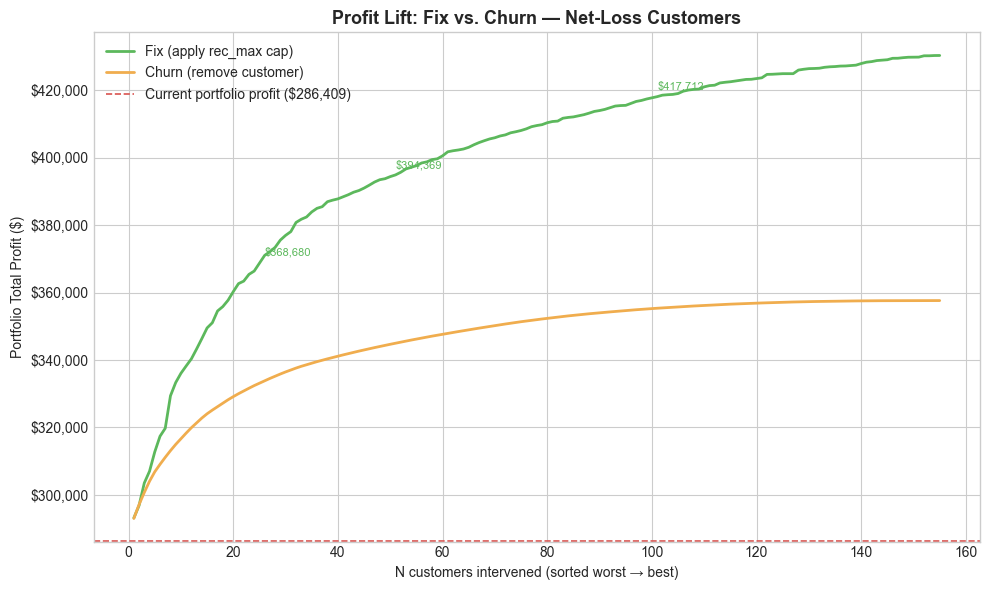

Saved: visuals/10b_phase2_customer_lift_curve.png


In [24]:
# Build lift curves: Fix vs. Churn — sort net-loss by worst actual profit first
nl_sorted       = nl.sort_values('total_profit').reset_index(drop=True)
profitable_sum  = pr['total_profit'].sum()
portfolio_base  = df['Profit'].sum()

fix_line   = []
churn_line = []

for n in range(1, len(nl_sorted) + 1):
    bottom_n = nl_sorted.iloc[:n]
    rest_nl  = nl_sorted.iloc[n:]
    # Fix: replace actual profit with counterfactual for the worst-n customers
    fix_line.append(
        profitable_sum + bottom_n['cf_total'].sum() + rest_nl['total_profit'].sum()
    )
    # Churn: remove worst-n customers entirely
    churn_line.append(
        profitable_sum + rest_nl['total_profit'].sum()
    )

x = range(1, len(nl_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, fix_line,   color='#5cb85c', linewidth=2.0, label='Fix (apply rec_max cap)')
ax.plot(x, churn_line, color='#f0ad4e', linewidth=2.0, label='Churn (remove customer)')
ax.axhline(portfolio_base, color='#d9534f', linewidth=1.2,
           linestyle='--', label=f'Current portfolio profit (${portfolio_base:,.0f})')

# Annotate key milestones
for n, label in [(25, 'N=25'), (50, 'N=50'), (100, 'N=100')]:
    ax.annotate(f'${fix_line[n-1]:,.0f}', xy=(n, fix_line[n-1]),
                xytext=(4, 6), textcoords='offset points', fontsize=8, color='#5cb85c')

ax.set_xlabel('N customers intervened (sorted worst → best)')
ax.set_ylabel('Portfolio Total Profit ($)')
ax.set_title('Profit Lift: Fix vs. Churn — Net-Loss Customers',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('../visuals/10b_phase2_customer_lift_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visuals/10b_phase2_customer_lift_curve.png')

In [25]:
# Summary table: portfolio profit at key N milestones
print(f"{'N':>6} | {'Fix ($)':>12} | {'Fix gain':>10} | {'Churn ($)':>12} | {'Churn gain':>10}")
print('-' * 60)
for n in [10, 25, 50, 100, 155]:
    fp = fix_line[n-1]
    cp = churn_line[n-1]
    print(f"{n:>6} | ${fp:>11,.0f} | +${fp-portfolio_base:>8,.0f} | "
          f"${cp:>11,.0f} | +${cp-portfolio_base:>8,.0f}")

     N |      Fix ($) |   Fix gain |    Churn ($) | Churn gain
------------------------------------------------------------
    10 | $    336,057 | +$  49,648 | $    316,675 | +$  30,265
    25 | $    368,680 | +$  82,271 | $    333,133 | +$  46,724
    50 | $    394,369 | +$ 107,960 | $    344,664 | +$  58,255
   100 | $    417,712 | +$ 131,303 | $    355,246 | +$  68,837
   155 | $    430,280 | +$ 143,871 | $    357,621 | +$  71,212


### Key Findings — Section 2.2

**9 out of 10 net-loss customers are fixable with the discount rule alone.**
141 of the 155 (91%) turn profitable once the Section 1.1 caps are applied to their orders. No need to drop them — just stop over-discounting them.

**Only 14 customers are genuinely structural — and they barely move the needle.**
Together they add up to just $6,963 (9.8% of the leakage). They stay unprofitable even at capped discounts, so they need a case-by-case look (renegotiate, reprice, or let go), not a company-wide policy.

**Fixing always beats dropping the customer.**
At every point on the curve, capping discounts recovers far more profit than churning. At 50 customers: **+$107,960** from fixing vs. **+$58,255** from churning. Dropping a customer also throws away their revenue, so the math never favors it.

**The recommendation is robust to the elasticity assumption.**
The Fix gains assume customers keep buying once their discount is capped (zero elasticity — the optimistic end). §1.4 models the opposite extreme: every over-discounted customer walks away. Both scenarios converge near the same place — Fix lands the portfolio at **~$430K**, §1.4's total-loss floor at **$431,742** — versus **$286K** today. Whether these customers stay or leave, capping the discount wins. That convergence is the strongest evidence the recommendation does not rest on the elasticity assumption.

**Sections 1 and 2 land on a single recommendation.**
Over-discounting destroys 77% of profit (§1.2) and explains 91% of the net-loss customers (§2.2). The same one lever — a 20% cap, with Tables and Supplies at 10% — fixes both. The remaining 14 accounts are a short, named list for manual review, not a strategy.

---
## Section 3: The 2017 Margin Slip

**Objective:** Sections 1–2 explained ~77% of the profit loss through discount policy, and showed the recommendation is robust to elasticity (§1.4 + §2.2 converge at ~$430K). One piece is still unexplained: the **temporal deterioration of 2017** — annual margin fell 13.4% → 12.7%, and Q4 2017 collapsed to 9.8% vs Q4 2016's 16.2%, *on higher sales*.

**Analytical frame:** a portfolio margin is a sales-weighted average, so it can only fall for two reasons:
$$\Delta\text{Margin} = \underbrace{\text{Mix effect}}_{\text{sold a worse product mix}} + \underbrace{\text{Rate effect}}_{\text{same products, worse margin}} + \text{Interaction}$$

Isolating which one dominates decides whether 2017 is a *new* problem (product mix) or the *same* discount disease from Section 1, intensified.

**Questions addressed in this section:**
- **3.1** Was the 2017 margin slip caused by mix-shift or by price/discount erosion?
- **3.2** Q4 2017 had higher sales but half the margin of Q4 2016 — what changed?
- **3.3** Are the Jan 2015 / Jul 2014 margin craters policy events or isolated transactions?

---
## 3.1 — Mix-Shift vs. Price-Effect Decomposition

### Approach

Restrict to 2016 and 2017. For every sub-category compute its sales weight `w` and its weighted margin `m` in each year, then split the total margin change into three exact, additive pieces:

- **Mix** — margin moved purely because the sales mix changed (each sub-cat held at its 2016 margin).
- **Rate** — margin moved purely because each sub-category's own margin changed (mix held at 2016).
- **Interaction** — the small cross-term (sub-cats that shifted both weight and margin).

The three must sum exactly to the observed margin change — that is the built-in correctness check. A waterfall makes the dominant force visible at a glance. As a final step we check whether the sub-categories driving the rate effect also saw deeper discounts — closing the loop with Section 1.

In [26]:
# Section 3 setup — temporal columns (idempotent)
df['order_dt'] = pd.to_datetime(df['Order Date'])
df['year']     = df['order_dt'].dt.year
df['quarter']  = df['order_dt'].dt.quarter
df['ym']       = df['order_dt'].dt.strftime('%Y-%m')

# §3.1 — Mix vs. Rate decomposition, 2016 -> 2017
agg = (df[df['year'].isin([2016, 2017])]
       .groupby(['year', 'Sub-Category'])
       .agg(S=('Sales', 'sum'), P=('Profit', 'sum'))
       .reset_index())

a16 = agg[agg.year == 2016].set_index('Sub-Category')
a17 = agg[agg.year == 2017].set_index('Sub-Category')
cats = sorted(set(a16.index) | set(a17.index))
tot16, tot17 = a16.S.sum(), a17.S.sum()

recs = []
for c in cats:
    s16, p16 = a16.S.get(c, 0.0), a16.P.get(c, 0.0)
    s17, p17 = a17.S.get(c, 0.0), a17.P.get(c, 0.0)
    w16, w17 = s16 / tot16, s17 / tot17
    m16 = p16 / s16 if s16 else 0.0
    m17 = p17 / s17 if s17 else 0.0
    recs.append({'Sub-Category': c, 'w16': w16, 'w17': w17,
                 'm16': m16, 'm17': m17,
                 'mix':  (w17 - w16) * m16,
                 'rate': w16 * (m17 - m16),
                 'inter': (w17 - w16) * (m17 - m16)})
decomp = pd.DataFrame(recs)

M16 = a16.P.sum() / a16.S.sum()
M17 = a17.P.sum() / a17.S.sum()
MIX, RATE, INTER = decomp.mix.sum(), decomp.rate.sum(), decomp.inter.sum()

print(f"Margin 2016:      {M16:>7.2%}")
print(f"Margin 2017:      {M17:>7.2%}")
print(f"Delta Margin:     {(M17 - M16) * 100:>+6.2f} pp")
print("-" * 38)
print(f"  Mix effect:     {MIX * 100:>+6.2f} pp")
print(f"  Rate effect:    {RATE * 100:>+6.2f} pp")
print(f"  Interaction:    {INTER * 100:>+6.2f} pp")
print(f"  Sum (check):    {(MIX + RATE + INTER) * 100:>+6.2f} pp   (must equal Delta Margin)")

Margin 2016:       13.43%
Margin 2017:       12.74%
Delta Margin:      -0.68 pp
--------------------------------------
  Mix effect:      +1.17 pp
  Rate effect:     -2.23 pp
  Interaction:     +0.38 pp
  Sum (check):     -0.68 pp   (must equal Delta Margin)


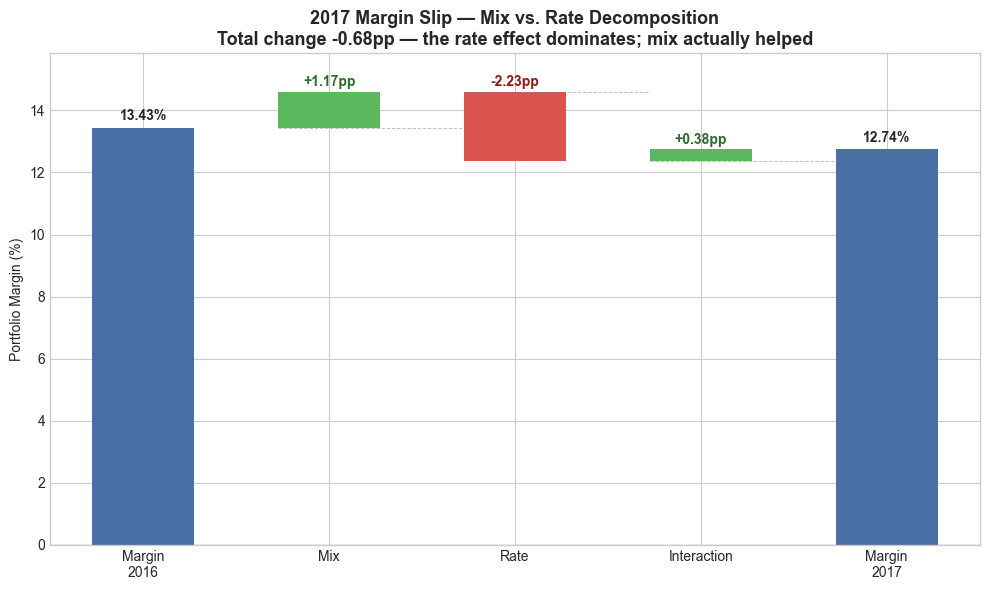

Saved: visuals/11a_phase2_margin_decomposition_waterfall.png


In [27]:
# Waterfall: Margin 2016 -> Mix -> Rate -> Interaction -> Margin 2017
labels = ['Margin\n2016', 'Mix', 'Rate', 'Interaction', 'Margin\n2017']
M16p, M17p = M16 * 100, M17 * 100
deltas = [MIX * 100, RATE * 100, INTER * 100]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(0, M16p, width=0.55, color='#4a6fa5')
ax.bar(4, M17p, width=0.55, color='#4a6fa5')
ax.text(0, M16p + 0.25, f'{M16p:.2f}%', ha='center', fontweight='bold')
ax.text(4, M17p + 0.25, f'{M17p:.2f}%', ha='center', fontweight='bold')

run = M16p
for i, d in enumerate(deltas, start=1):
    bottom = run if d >= 0 else run + d
    color = '#5cb85c' if d >= 0 else '#d9534f'
    ax.bar(i, abs(d), bottom=bottom, width=0.55, color=color)
    ax.text(i, max(run, run + d) + 0.18, f'{d:+.2f}pp', ha='center',
            fontweight='bold', color='#2d6a2d' if d >= 0 else '#8b1a1a')
    ax.plot([i - 0.275, i + 0.725], [run, run], color='gray', lw=0.7, ls='--', alpha=0.5)
    run += d

ax.set_xticks(range(5))
ax.set_xticklabels(labels)
ax.set_ylabel('Portfolio Margin (%)')
ax.set_ylim(0, max(M16p, M17p) * 1.18)
ax.set_title('2017 Margin Slip — Mix vs. Rate Decomposition\n'
             f'Total change {(M17 - M16) * 100:+.2f}pp — the rate effect dominates; mix actually helped',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('../visuals/11a_phase2_margin_decomposition_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visuals/11a_phase2_margin_decomposition_waterfall.png')

In [28]:
# Per-sub-category contribution + discount attribution (closing the loop with §1)
contrib = decomp.assign(
    m16_pct=lambda x: x.m16 * 100, m17_pct=lambda x: x.m17 * 100,
    mix_pp=lambda x: x['mix'] * 100, rate_pp=lambda x: x['rate'] * 100,
).sort_values('rate')

print("Top rate-effect contributors (most negative):")
print(contrib[['Sub-Category', 'm16_pct', 'm17_pct', 'mix_pp', 'rate_pp']]
      .head(5).round(2).to_string(index=False))

print("\nWeighted avg discount by year:")
for y in (2016, 2017):
    dd = df[df.year == y]
    print(f"  {y} overall: {(dd.Sales * dd.Discount).sum() / dd.Sales.sum():.1%}")
for c in ['Machines', 'Tables', 'Binders']:
    line = f"  {c:<9}"
    for y in (2016, 2017):
        dd = df[(df.year == y) & (df['Sub-Category'] == c)]
        line += f"  {y}={(dd.Sales * dd.Discount).sum() / dd.Sales.sum():.1%}"
    print(line)

Top rate-effect contributors (most negative):
Sub-Category  m16_pct  m17_pct  mix_pp  rate_pp
    Machines     5.20    -6.59   -0.17    -1.08
      Tables    -4.85   -13.37    0.08    -0.85
     Binders    20.56    10.54    0.36    -0.82
   Bookcases     0.81    -1.94   -0.00    -0.12
  Appliances    20.35    18.32    0.32    -0.09

Weighted avg discount by year:


  2016 overall: 13.3%


  2017 overall: 13.8%
  Machines   2016=15.7%  2017=26.4%
  Tables     2016=18.7%  2017=24.4%
  Binders    2016=20.3%  2017=23.5%


### Key Findings — Section 3.1

**The 2017 slip is a rate effect, not a mix shift.** Margin fell 13.43% → 12.74% (−0.68pp). Decomposed: **Mix +1.17pp · Rate −2.23pp · Interaction +0.38pp** (sum = −0.68pp, exact). The product mix actually *improved* margin slightly — the entire decline, and then some, comes from the same products selling at worse margins.

**Three sub-categories drive the rate effect.** Machines (margin 5.2% → −6.6%), Tables (−4.9% → −13.4%) and Binders (20.6% → 10.5%) together contribute ≈ −2.75pp of rate erosion — more than the net total, partly offset by others.

**The rate effect is discount.** Those exact three saw the sharpest discount increases in 2017: Machines **15.7% → 26.4%**, Tables **18.7% → 24.4%**, Binders **20.3% → 23.5%**. Overall weighted discount barely moved (13.3% → 13.8%) — this is concentrated deepening, not a broad shift.

**Conclusion: 2017 is not a new problem.** It is the Section 1 discount disease, intensified in Machines / Tables / Binders. No separate product-mix recommendation is needed — the same single lever covers it.

---
## 3.2 — Q4 2017 Drill-Down

### Approach

Q4 2017 sold *more* than Q4 2016 ($280K vs $236K) yet earned far less margin (9.8% vs 16.2%). Compare the two quarters head-to-head on the three things that can move margin: **discount depth**, **product mix** (Furniture share), and **concentration** (do a few large loss orders explain the gap?).

In [29]:
# Q4 2016 vs Q4 2017 head-to-head
q = df[df.quarter == 4]
rows = []
for y in (2016, 2017):
    qy = q[q.year == y]
    rows.append({
        'Quarter': f'Q4 {y}',
        'Sales': qy.Sales.sum(),
        'Profit': qy.Profit.sum(),
        'Margin': qy.Profit.sum() / qy.Sales.sum(),
        'Wtd Discount': (qy.Sales * qy.Discount).sum() / qy.Sales.sum(),
        'Furniture Share': qy[qy.Category == 'Furniture'].Sales.sum() / qy.Sales.sum(),
        'Orders': qy['Order ID'].nunique(),
    })
q4 = pd.DataFrame(rows)

disp = q4.copy()
disp['Sales'] = disp.Sales.map('${:,.0f}'.format)
disp['Profit'] = disp.Profit.map('${:,.0f}'.format)
disp['Margin'] = disp.Margin.map('{:.1%}'.format)
disp['Wtd Discount'] = disp['Wtd Discount'].map('{:.1%}'.format)
disp['Furniture Share'] = disp['Furniture Share'].map('{:.1%}'.format)
print(disp.to_string(index=False))

print("\nQ4 2017 — top 5 loss orders:")
t5 = q[q.year == 2017].nsmallest(5, 'Profit')[
    ['Customer Name', 'Sub-Category', 'Sales', 'Discount', 'Profit']].copy()
t5['Sales'] = t5.Sales.map('${:,.0f}'.format)
t5['Discount'] = t5.Discount.map('{:.0%}'.format)
t5['Profit'] = t5.Profit.map('${:,.0f}'.format)
print(t5.to_string(index=False))

Quarter    Sales  Profit Margin Wtd Discount Furniture Share  Orders
Q4 2016 $236,099 $38,140  16.2%        11.4%           34.0%     464
Q4 2017 $280,054 $27,449   9.8%        14.8%           32.3%     632

Q4 2017 — top 5 loss orders:
 Customer Name Sub-Category  Sales Discount  Profit
Grant Thornton     Machines $8,000      50% $-3,840
 Henry Goldwyn      Binders $1,890      80% $-2,929
   Nathan Cano      Binders $1,525      80% $-2,288
 Tracy Hopkins      Binders $1,633      70% $-1,307
   Dean percer       Tables $2,314      40% $-1,003


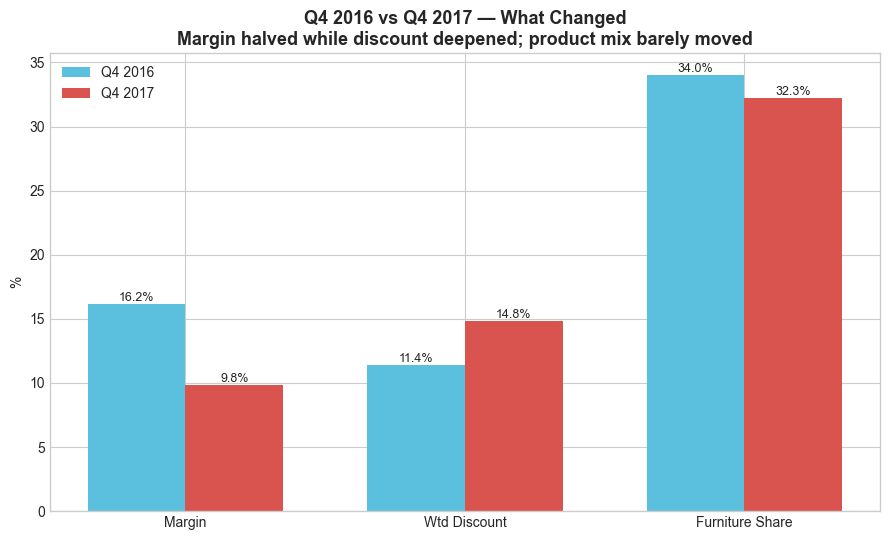

Saved: visuals/11b_phase2_q4_2016_vs_2017.png


In [30]:
# Visual — Q4 2016 vs Q4 2017 on the three margin drivers
metrics = ['Margin', 'Wtd Discount', 'Furniture Share']
v16 = [q4.loc[0, m] * 100 for m in metrics]
v17 = [q4.loc[1, m] * 100 for m in metrics]
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - w / 2, v16, w, label='Q4 2016', color='#5bc0de')
b2 = ax.bar(x + w / 2, v17, w, label='Q4 2017', color='#d9534f')
ax.bar_label(b1, fmt='%.1f%%', fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('%')
ax.set_title('Q4 2016 vs Q4 2017 — What Changed\n'
             'Margin halved while discount deepened; product mix barely moved',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/11b_phase2_q4_2016_vs_2017.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visuals/11b_phase2_q4_2016_vs_2017.png')

### Key Findings — Section 3.2

**Q4 2017's collapse is the same story, zoomed in.** Weighted discount jumped **11.4% → 14.8%** (+3.4pp) while Furniture's share of sales was essentially flat (34.0% → 32.3%). Not a mix shift — deeper discounting, exactly as §3.1 predicted.

**The damage concentrates in a handful of deep-discount orders.** The five worst Q4 2017 orders are Machines, Binders and Tables at **40–80% discount**, led by Grant Thornton (Machines, $8,000 at 50% → −$3,840) — the same account flagged as structural in §2.2. Same names, same products, same mechanism as §1 and §2.

---
## 3.3 — Anomaly Audit: Jan 2015 & Jul 2014

### Approach

Phase 1's monthly heatmap flagged two isolated craters: **Jan 2015 (−18.1%)** and **Jul 2014 (−2.5%)**. Are these *policy events* (loss spread across many orders) or *isolated transactions* (one or two catastrophic orders)? Drill into each month, rank transactions by loss, and measure how much of the month's damage the single worst order explains.

In [31]:
# Anomaly audit — Jan 2015 & Jul 2014
for month, label in [('2015-01', 'Jan 2015'), ('2014-07', 'Jul 2014')]:
    s = df[df.ym == month]
    net = s.Profit.sum()
    gross_loss = s.loc[s.Profit < 0, 'Profit'].sum()
    worst = s.nsmallest(5, 'Profit')[
        ['Customer Name', 'Sub-Category', 'Sales', 'Discount', 'Profit']].copy()
    p1 = worst.iloc[0].Profit

    print(f"=== {label} ===")
    print(f"Net profit: ${net:,.0f}   |   transactions: {len(s)}   |   "
          f"gross losses: ${gross_loss:,.0f}")
    print(f"Worst single txn: ${p1:,.0f}  =  {p1 / gross_loss:.0%} of the month's gross losses")
    w = worst.copy()
    w['Sales'] = w.Sales.map('${:,.0f}'.format)
    w['Discount'] = w.Discount.map('{:.0%}'.format)
    w['Profit'] = w.Profit.map('${:,.0f}'.format)
    print(w.to_string(index=False))
    print()

=== Jan 2015 ===
Net profit: $-3,281   |   transactions: 58   |   gross losses: $-4,481
Worst single txn: $-1,862  =  42% of the month's gross losses
  Customer Name Sub-Category  Sales Discount  Profit
    Joseph Holt       Tables $4,298      40% $-1,862
Victoria Wilson     Machines $1,188      70%   $-950
       Amy Hunt    Bookcases $1,352      32%   $-438
  Michael Moore       Tables $1,018      40%   $-373
Joni Sundaresam  Furnishings   $255      60%   $-312

=== Jul 2014 ===
Net profit: $-841   |   transactions: 143   |   gross losses: $-4,605
Worst single txn: $-3,702  =  80% of the month's gross losses
   Customer Name Sub-Category  Sales Discount  Profit
     Luke Foster      Binders $2,178      80% $-3,702
Katherine Murray       Chairs   $981      30%   $-140
    Kunst Miller       Chairs   $674      20%   $-110
     Harry Marie       Chairs   $658      30%    $-94
      Ed Braxton       Tables   $502      20%    $-88



### Key Findings — Section 3.3

**Both anomalies are single-transaction outliers — hypothesis H7 confirmed.**

- **Jan 2015** (−$3,281 net, $4,481 gross losses): one Tables order — Joseph Holt, $4,298 at 40% discount → −$1,862 — is **42% of the month's gross losses**. The five worst orders are all Tables / Machines / Bookcases at 32–70% discount.
- **Jul 2014** (−$841 net, $4,605 gross losses): one Binders order — Luke Foster, $2,178 at **80% discount** → −$3,702 — is **80% of the month's gross losses**, and on its own *larger than the entire month's net loss*. Remove that single order and July 2014 was profitable.

These are not policy events. They are extreme-discount outliers — the §1 disease in its most concentrated form. The Phase 1 loose end is closed.

---
## Phase 2 — Closing Synthesis

Sections 1–3 converge on a single diagnosis:

- **§1** Over-discounting destroys 77% of profit; a 20% cap (Tables/Supplies at 10%) recovers ~$228K (+79.5%).
- **§1.4 + §2.2** The recommendation is robust to elasticity — profit lands ≈ $430K whether over-discounted customers stay or walk away.
- **§2** Discount is the *sole* discriminator of net-loss customers; 91% (141 of 155) are fixable by that same cap; only 14 need manual review.
- **§3** The 2017 margin slip is the same discount disease (rate effect −2.23pp, mix actually +1.17pp), concentrated in Machines/Tables/Binders; the historical anomalies are isolated extreme-discount transactions.

**One problem, one lever.** Every thread in Phase 2 — products, customers, time — traces back to discount policy. The recommendation is unified, quantified, and robust to its key assumption. The detailed action matrix and expected-impact summary are consolidated in **Section 4 — Synthesis & Recommendations**.